
Modeling dataset preview:


,log_ret,RV_21,Parkinson_21
Date,,,
2013-02-01,-0.101633,0.175075,0.145446
2013-02-04,0.128577,0.217062,0.148217
2013-02-05,-0.066950,0.221252,0.149710
2013-02-06,-0.022854,0.222410,0.149155
2013-02-07,0.006689,0.222165,0.152331



GARCH(1,1) Summary:
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8673.75
Distribution:      Standardized Student's t   AIC:                           17357.5
Method:                  Maximum Likelihood   BIC:                           17386.8
                                              No. Observations:                 2575
Date:                      Mon, Nov 17 2025   Df Residuals:                     2574
Time:                              13:39:37   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
--------------------------------------------------------------------

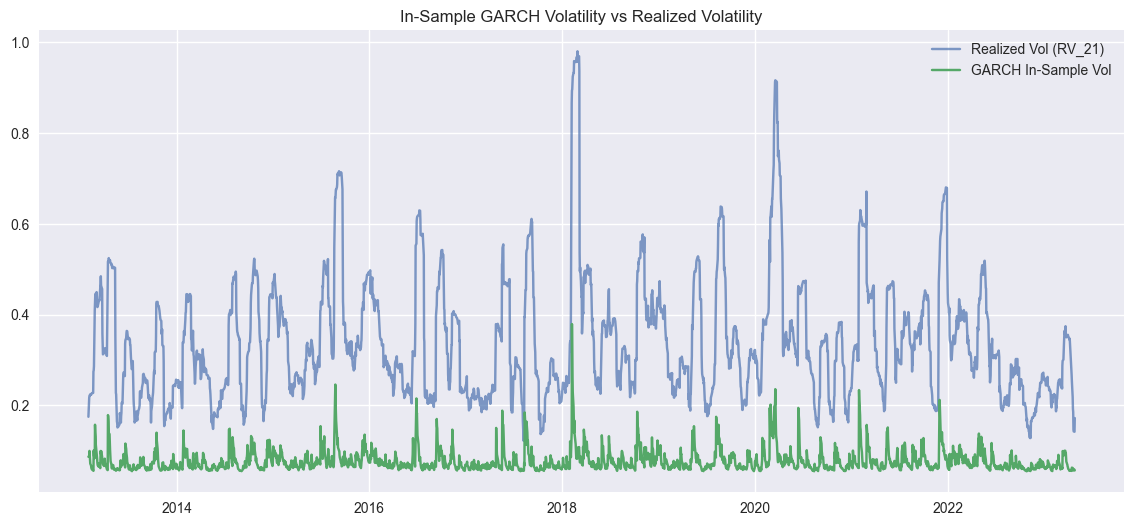

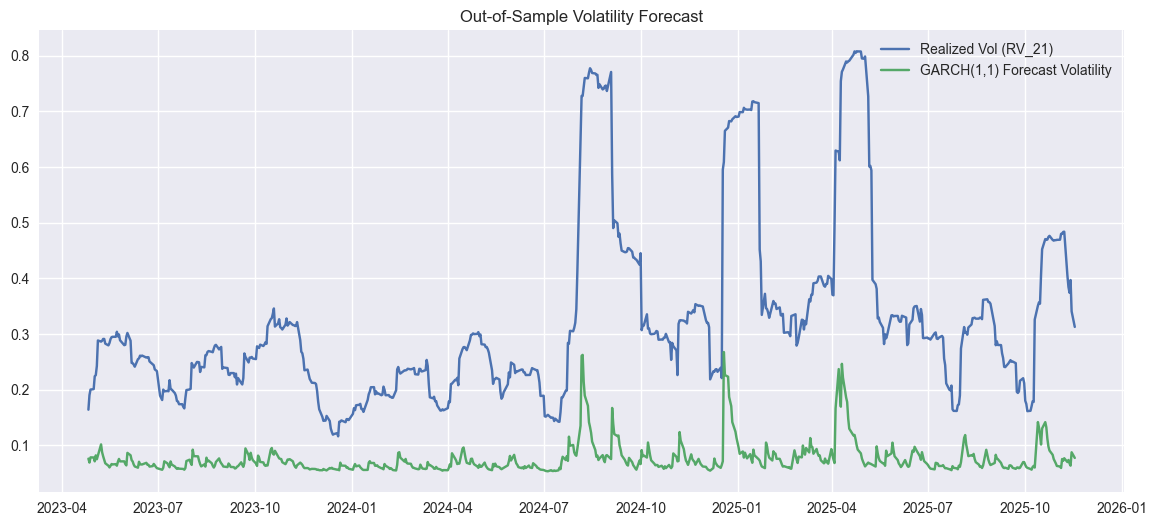


Forecast Performance vs RV_21:
MSE: 0.080964
MAE: 0.245867


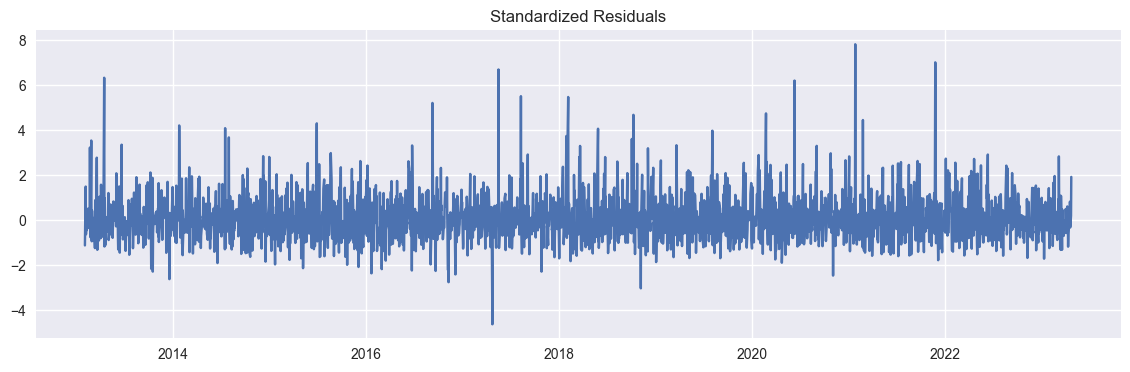

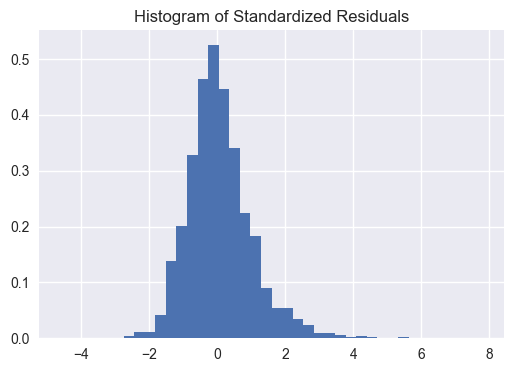


Saved GARCH forecasts to: ../data/processed/garch_forecasts.csv


In [8]:
# ===========================================
# Notebook 03 — GARCH(1,1) Volatility Modeling
# ===========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
import os

plt.style.use("seaborn-v0_8")

# Load Data
df_raw = pd.read_csv(
    "../data/raw/VIX_daily.csv",
    parse_dates=["Date"]
).set_index("Date")

df_rv = pd.read_csv(
    "../data/processed/realized_vol.csv",
    parse_dates=["Date"]
).set_index("Date")

# Merge Return Dataset
returns = np.log(df_raw["Close"]).diff().dropna()
returns.name = "log_ret"

df_model = pd.concat(
    [returns, df_rv[["RV_21", "Parkinson_21"]]],
    axis=1
).dropna()

print("\nModeling dataset preview:")
display(df_model.head())

# Train/Test Split (80% training - 20% testing)
split_idx = int(len(df_model) * 0.80)
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

# Scale to percentage returns
r_train = train["log_ret"] * 100 
r_test  = test["log_ret"] * 100

# Fit GARCH(1,1) on Train Dataset
garch11 = arch_model(
    r_train,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch11_result = garch11.fit(update_freq=20, disp="off")

print("\nGARCH(1,1) Summary:")
print(garch11_result.summary())

# Estimated Conditional Volatility
cond_vol_in = garch11_result.conditional_volatility / 100.0
cond_vol_in.index = train.index

# Plot Estimated Conditional Volatility vs Realized Vol
'''
This plot compares the GARCH(1,1) model’s estimated conditional volatility with
the observed 21-day realized volatility (RV_21) inside the training period.

After generating the plot, we can see that GARCH captures the overall volatility clustering behavior 
(periods of high and low volatility), but it remains smoother and generally lower than RV_21.
This confirms a known limitation of simple GARCH models: they react slowly to large volatility spikes 
and tend to underpredict extreme movements.
'''
plt.figure(figsize=(14, 6))
plt.plot(train["RV_21"], label="Realized Vol (RV_21)", alpha=0.7)
plt.plot(cond_vol_in, label="GARCH In-Sample Vol")
plt.title("In-Sample GARCH Volatility vs Realized Volatility")
plt.legend()
plt.show()

# Rolling 1-step-ahead Forecast Loop (FIXED)
rolling_forecasts = []
history = r_train.copy()

for t in range(len(r_test)):
    model = arch_model(
        history,
        mean="Constant",
        vol="GARCH",
        p=1, q=1,
        dist="t"
    )
    result = model.fit(disp="off")

    forecast = result.forecast(horizon=1)
    sigma2 = forecast.variance.iloc[-1, 0]
    sigma  = np.sqrt(sigma2)

    rolling_forecasts.append(sigma)

    # Add actual next return
    new_index = [r_test.index[t]]
    history = pd.concat([history, pd.Series([r_test.iloc[t]], index=new_index)])

vol_forecast = pd.Series(rolling_forecasts, index=r_test.index) / 100.0

# Plot Forecast vs Realized Vol
'''
This plot shows true out-of-sample forecasting ability using a rolling 1-step-ahead procedure.

After generating the plot, we can see that model correctly identifies changes in volatility regimes 
but still underestimates the magnitude of large spikes, which is typical for GARCH(1,1).
'''
plt.figure(figsize=(14, 6))
plt.plot(test["RV_21"], label="Realized Vol (RV_21)")
plt.plot(vol_forecast, label="GARCH(1,1) Forecast Volatility")
plt.title("Out-of-Sample Volatility Forecast")
plt.legend()
plt.show()

# Forecast Evaluation
y_true = test["RV_21"]
y_pred = vol_forecast

mse = ((y_true - y_pred)**2).mean()
mae = (y_true - y_pred).abs().mean()

print("\nForecast Performance vs RV_21:")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")

# Residual Diagnostics
resid = garch11_result.resid / garch11_result.conditional_volatility
resid.index = train.index

# Plot Standardized Residuals
'''
Standardized residuals represent how much each return deviates from the volatility predicted by GARCH.

After generating the plot, we can see that the residuals are centered around zero 
but still show occasional large shocks, suggesting heavy-tailed behavior in the VIX.

This is one reason the Student-t distribution is appropriate for this model.
'''
plt.figure(figsize=(14,4))
plt.plot(resid)
plt.title("Standardized Residuals")
plt.show()

# Plot Histogram of Standardized Residuals
'''
After generating the plot, we can see that the distribution of standardized residuals 
appears peaked at zero with heavy tails, 
consistent with a Student-t shape rather than a normal distribution.

This confirms that VIX returns contain extreme outliers and tail risk, 
working best with a Student-t innovation.
'''
plt.figure(figsize=(6,4))
plt.hist(resid, bins=40, density=True)
plt.title("Histogram of Standardized Residuals")
plt.show()

# Save Output
os.makedirs("../data/processed", exist_ok=True)
garch_output = pd.DataFrame({
    "GARCH_vol_forecast": vol_forecast,
    "RV_21": test["RV_21"]
})
out_path = "../data/processed/garch_forecasts.csv"
garch_output.to_csv(out_path)
print("\nSaved GARCH forecasts to:", out_path)